# 04 — Churn Labeling

**Sửa lỗi leakage của bản cũ.** Không còn gán `is_churn = (Recency > 180)`. Nhãn được lấy từ **tương lai** `[t, t+H)`: có mua hợp lệ → 0, không mua → 1. Với `t=01/06/2011`, `H=180`, cửa sổ nhãn kết thúc trước `28/11/2011`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

features_path = '../data/processed/customer_features.csv'
transactions_path = '../data/interim/transactions_cleaned.csv'
output_path = '../data/processed/customer_features_labeled.csv'

features = pd.read_csv(features_path)
trans = pd.read_csv(transactions_path, parse_dates=['InvoiceDate'])

prediction_date = pd.Timestamp('2011-06-01')
horizon_days = 180
label_end = prediction_date + pd.Timedelta(days=horizon_days)

print('t =', prediction_date.date())
print('H =', horizon_days, 'ngày')
print('Cửa sổ nhãn: [', prediction_date.date(), ',', label_end.date(), ')')
print('Ngày cuối dữ liệu:', trans['InvoiceDate'].max())
assert trans['InvoiceDate'].max() >= label_end, 'Không đủ thời gian quan sát H ngày để tạo nhãn.'

t = 2011-06-01
H = 180 ngày
Cửa sổ nhãn: [ 2011-06-01 , 2011-11-28 )
Ngày cuối dữ liệu: 2011-12-09 12:50:00


In [2]:
# Chỉ giao dịch MUA hợp lệ trong tương lai mới chứng minh khách quay lại mua.
future_purchases = trans[
    (trans['transaction_type'] == 'purchase') &
    (trans['InvoiceDate'] >= prediction_date) &
    (trans['InvoiceDate'] < label_end)
].copy()

returned_ids = set(future_purchases['Customer ID'].dropna().unique())

labeled = features.copy()
labeled['is_churn'] = (~labeled['Customer ID'].isin(returned_ids)).astype(int)

print('\nSố khách:', len(labeled))
print('Phân bố nhãn:')
print(labeled['is_churn'].value_counts())
print('\nTỷ lệ nhãn:')
print(labeled['is_churn'].value_counts(normalize=True).rename('ratio'))

# Kiểm tra quan trọng: nhãn KHÔNG được tạo trực tiếp từ Recency.
ct = pd.crosstab(pd.cut(labeled['Recency'], bins=[-1,30,60,90,120,180,np.inf]), labeled['is_churn'])
print('\nĐối chiếu Recency và nhãn tương lai (để kiểm tra không phải rule Recency>180):')
print(ct)


Số khách: 2658
Phân bố nhãn:
is_churn
0    1854
1     804
Name: count, dtype: int64

Tỷ lệ nhãn:
is_churn
0    0.697517
1    0.302483
Name: ratio, dtype: float64

Đối chiếu Recency và nhãn tương lai (để kiểm tra không phải rule Recency>180):
is_churn          0    1
Recency                 
(-1.0, 30.0]    870  173
(30.0, 60.0]    334  139
(60.0, 90.0]    270  171
(90.0, 120.0]   158  129
(120.0, 180.0]  222  192



Khoảng cách mua lặp lại trên development period:
count    17998.000000
mean        51.494722
std         61.099220
min          1.000000
50%         30.000000
75%         65.000000
90%        128.300000
95%        176.000000
max        540.000000
Name: gap_days, dtype: float64
Tỷ lệ gap <= 90 ngày: 82.86%
Tỷ lệ gap <= 120 ngày: 88.88%
Tỷ lệ gap <= 180 ngày: 95.23%


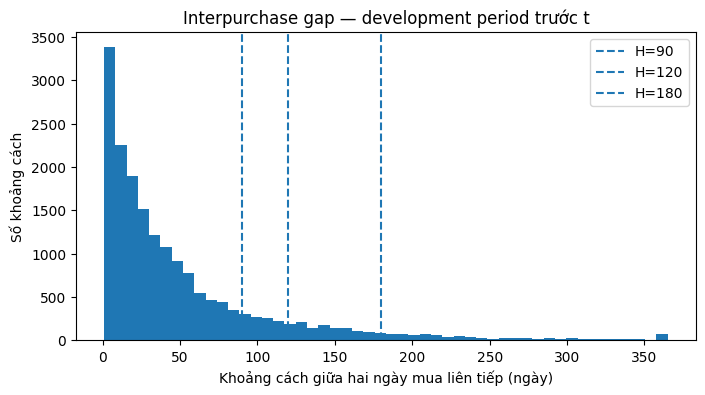

In [3]:
# Phân tích sơ bộ khoảng cách mua trên GIAI ĐOẠN PHÁT TRIỂN trước t
# Dùng để kiểm tra H=90/120/180; không dùng test cuối để chọn H.
dev_purchases = trans[
    (trans['transaction_type'] == 'purchase') &
    (trans['InvoiceDate'] < prediction_date)
].copy()
dev_purchases['PurchaseDate'] = dev_purchases['InvoiceDate'].dt.normalize()

daily = dev_purchases[['Customer ID','PurchaseDate']].drop_duplicates().sort_values(['Customer ID','PurchaseDate'])
daily['gap_days'] = daily.groupby('Customer ID')['PurchaseDate'].diff().dt.days
gaps = daily['gap_days'].dropna()

print('\nKhoảng cách mua lặp lại trên development period:')
print(gaps.describe(percentiles=[.5,.75,.9,.95]))
for h in [90,120,180]:
    print(f'Tỷ lệ gap <= {h} ngày: {(gaps.le(h).mean()*100):.2f}%')

plt.figure(figsize=(8,4))
plt.hist(gaps.clip(upper=365), bins=50)
plt.axvline(90, linestyle='--', label='H=90')
plt.axvline(120, linestyle='--', label='H=120')
plt.axvline(180, linestyle='--', label='H=180')
plt.xlabel('Khoảng cách giữa hai ngày mua liên tiếp (ngày)')
plt.ylabel('Số khoảng cách')
plt.title('Interpurchase gap — development period trước t')
plt.legend()
plt.show()

In [4]:
labeled.to_csv(output_path, index=False)
print(f'\nĐã lưu {output_path}')
print('Đây là file đầu vào cho bước 05_model_training.ipynb.')


Đã lưu ../data/processed/customer_features_labeled.csv
Đây là file đầu vào cho bước 05_model_training.ipynb.
